In [ ]:
!pip install numpy pandas matplotlib scipy tensorflow

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
!pip install mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 62.4 MB/s eta 0:00:00


In [ ]:
import mne
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
# Your dataset path will then be: '/content/drive/MyDrive/multi-modal_dataset/03FH'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Searching for files and preparing dataset...
Processing: /content/drive/MyDrive/multi-modal_dataset/LK27/scientisst_chest.edf
Processing: /content/drive/MyDrive/multi-modal_dataset/ME93/scientisst_chest.edf
Processing: /content/drive/MyDrive/multi-modal_dataset/KF93/scientisst_chest.edf
Processing: /content/drive/MyDrive/multi-modal_dataset/H39D/scientisst_chest.edf


/tmp/ipykernel_461/3910695163.py:18: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)


Processing: /content/drive/MyDrive/multi-modal_dataset/LDM5/scientisst_chest.edf


/tmp/ipykernel_461/3910695163.py:18: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)


Processing: /content/drive/MyDrive/multi-modal_dataset/K2Q2/scientisst_chest.edf
Processing: /content/drive/MyDrive/multi-modal_dataset/KS03/scientisst_chest.edf
Processing: /content/drive/MyDrive/multi-modal_dataset/LAS2/scientisst_chest.edf
Processing: /content/drive/MyDrive/multi-modal_dataset/JD3K/scientisst_chest.edf


...

Processing: /content/drive/MyDrive/multi-modal_dataset/AP3H/scientisst_chest.edf
Processing: /content/drive/MyDrive/multi-modal_dataset/93DK/scientisst_chest.edf


/tmp/ipykernel_461/3910695163.py:18: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)


Processing: /content/drive/MyDrive/multi-modal_dataset/03FH/scientisst_chest.edf


/tmp/ipykernel_461/3910695163.py:18: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(path, preload=True, verbose=False)


Processing: /content/drive/MyDrive/multi-modal_dataset/3RFH/scientisst_chest.edf
Total training windows: 55132
Starting global training...
Epoch 1/15
690/690 ━━━━━━━━━━━━━━━━━━━━ 196s 278ms/step - loss: 1.1154 - val_loss: 1.9817
Epoch 2/15
690/690 ━━━━━━━━━━━━━━━━━━━━ 200s 291ms/step - loss: 0.9054 - val_loss: 2.0565
Epoch 3/15
690/690 ━━━━━━━━━━━━━━━━━━━━ 217s 312ms/step - loss: 0.8417 - val_loss: 1.9709
Epoch 4/15
690/690 ━━━━━━━━━━━━━━━━━━━━ 191s 276ms/step - loss: 0.8461 - val_loss: 2.1114
Epoch 5/15
690/690 ━━━━━━━━━━━━━━━━━━━━ 203s 294ms/step - loss: 0.8205 - val_loss: 2.0665
Epoch 6/15
690/690 ━━━━━━━━━━━━━━━━━━━━ 261s 293ms/step - loss: 0.8158 - val_loss: 2.0062
Epoch 7/15
690/690 ━━━━━━━━━━━━━━━━━━━━ 203s 294ms/step - loss: 0.7803 - val_loss: 2.0757
Epoch 8/15
690/690 ━━━━━━━━━━━━━━━━━━━━ 254s 283ms/step - loss: 0.7831 - val_loss: 2.1659
Epoch 9/15
690/690 ━━━━━━━━━━━━━━━━━━━━ 238s 335ms/step - loss: 0.7692 - val_loss: 2.1596
Epoch 10/15
690/690 ━━━━━━━━━━━━━━━━━━━━ 231s 290ms

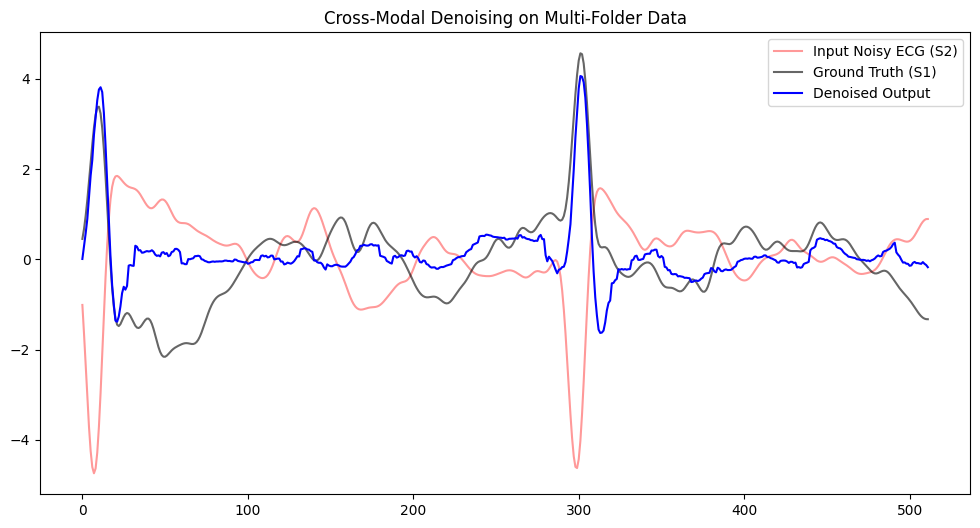

In [ ]:
import os
import numpy as np
import mne
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.signal import butter, filtfilt
import tensorflow as tf
from tensorflow.keras import layers, Model
from google.colab import drive

# 1. Mount Drive and Define Base Path
drive.mount('/content/drive')
BASE_PATH = '/content/drive/MyDrive/multi-modal_dataset'

# 2. Refined Data Loading & Preprocessing
def load_and_preprocess_file(path):
    try:
        raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
        ch_names = raw.ch_names
        data = raw.get_data()

        # Check for required channels
        required = ['ecg:gel', 'ecg:dry', 'acc_chest:x', 'acc_chest:y', 'acc_chest:z']
        if not all(ch in ch_names for ch in required):
            print(f"Skipping {path}: Missing required channels.")
            return None, None

        # Extract Channels
        s1_clean = data[ch_names.index('ecg:gel')]
        s2_noisy = data[ch_names.index('ecg:dry')]
        acc_x = data[ch_names.index('acc_chest:x')]
        acc_y = data[ch_names.index('acc_chest:y')]
        acc_z = data[ch_names.index('acc_chest:z')]

        # A. Calculate ACC Magnitude
        acc_mag = np.sqrt(acc_x**2 + acc_y**2 + acc_z**2)

        # B. Bandpass Filter (0.5 - 40 Hz)
        fs = int(raw.info['sfreq'])
        nyq = 0.5 * fs
        b, a = butter(3, [0.5/nyq, 40/nyq], btype='band')
        s1_clean = filtfilt(b, a, s1_clean)
        s2_noisy = filtfilt(b, a, s2_noisy)

        # C. Normalize per file to handle gain differences
        scaler_in = StandardScaler()
        scaler_out = StandardScaler()

        X_raw = np.stack([s2_noisy, acc_mag], axis=1)
        X_scaled = scaler_in.fit_transform(X_raw)
        y_scaled = scaler_out.fit_transform(s1_clean.reshape(-1, 1))

        return X_scaled, y_scaled
    except Exception as e:
        print(f"Error processing {path}: {e}")
        return None, None

# 3. Windowing Function
def create_windows(X, y, window_size=512):
    n_windows = len(X) // window_size
    X_win = X[:n_windows*window_size].reshape(-1, window_size, 2)
    y_win = y[:n_windows*window_size].reshape(-1, window_size, 1)
    return X_win, y_win

# 4. Dataset Aggregation Loop
all_X = []
all_y = []

print("Searching for files and preparing dataset...")
for root, dirs, files in os.walk(BASE_PATH):
    for file in files:
        if file == 'scientisst_chest.edf':
            file_path = os.path.join(root, file)
            print(f"Processing: {file_path}")

            X_scaled, y_scaled = load_and_preprocess_file(file_path)
            if X_scaled is not None:
                X_win, y_win = create_windows(X_scaled, y_scaled)
                all_X.append(X_win)
                all_y.append(y_win)

# Concatenate all subjects into one dataset
X_train_full = np.concatenate(all_X, axis=0)
y_train_full = np.concatenate(all_y, axis=0)

print(f"Total training windows: {len(X_train_full)}")

# 5. U-Net Architecture
def build_unet(window_size=512):
    inputs = layers.Input(shape=(window_size, 2))
    # Encoder
    c1 = layers.Conv1D(32, 3, activation='relu', padding='same')(inputs)
    p1 = layers.MaxPooling1D(2)(c1)
    c2 = layers.Conv1D(64, 3, activation='relu', padding='same')(p1)
    p2 = layers.MaxPooling1D(2)(c2)
    # Bottleneck
    b1 = layers.Conv1D(128, 3, activation='relu', padding='same')(p2)
    # Decoder
    u1 = layers.UpSampling1D(2)(b1)
    m1 = layers.Concatenate()([u1, c2])
    c3 = layers.Conv1D(64, 3, activation='relu', padding='same')(m1)
    u2 = layers.UpSampling1D(2)(c3)
    m2 = layers.Concatenate()([u2, c1])
    c4 = layers.Conv1D(32, 3, activation='relu', padding='same')(m2)
    outputs = layers.Conv1D(1, 3, activation='linear', padding='same')(c4)
    return Model(inputs, outputs)

# 6. Loss and Training
def correlation_loss(y_true, y_pred):
    x = y_true - tf.reduce_mean(y_true)
    y = y_pred - tf.reduce_mean(y_pred)
    corr = tf.reduce_sum(x * y) / (tf.sqrt(tf.reduce_sum(x**2)) * tf.sqrt(tf.reduce_sum(y**2)) + 1e-8)
    return 1 - corr

def total_loss(y_true, y_pred):
    return tf.reduce_mean(tf.square(y_true - y_pred)) + (0.5 * correlation_loss(y_true, y_pred))

model = build_unet()
model.compile(optimizer='adam', loss=total_loss)

# Train on the aggregated dataset
print("Starting global training...")
history = model.fit(X_train_full, y_train_full, epochs=15, batch_size=64, validation_split=0.2, verbose=1)

# 7. Verification Plot
sample_idx = np.random.randint(0, len(X_train_full))
prediction = model.predict(X_train_full[sample_idx:sample_idx+1])

plt.figure(figsize=(12, 6))
plt.plot(X_train_full[sample_idx, :, 0], label='Input Noisy ECG (S2)', color='red', alpha=0.4)
plt.plot(y_train_full[sample_idx, :, 0], label='Ground Truth (S1)', color='black', alpha=0.6)
plt.plot(prediction[0, :, 0], label='Denoised Output', color='blue', linewidth=1.5)
plt.title("Cross-Modal Denoising on Multi-Folder Data")
plt.legend()
plt.show()

------------------------------
Sample Index: 30504
Percentage Overlap: 67.07%
Initial SNR (S2): -5.41 dB
Final SNR (Denoised): 2.48 dB
SNR Improvement: 7.89 dB
------------------------------


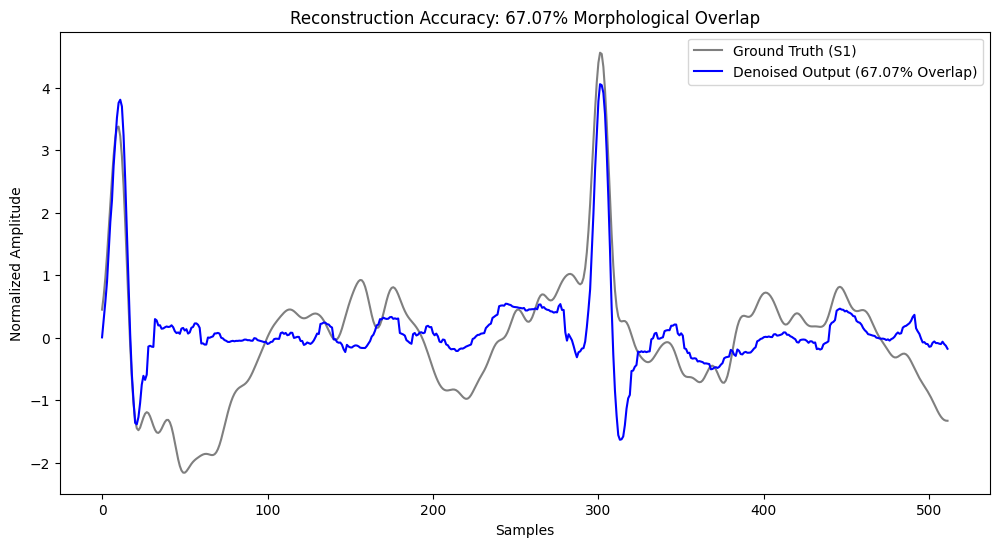

In [ ]:
from scipy.stats import pearsonr

# 1. Extract signals for the selected sample
# ground_truth (S1) and prediction (Denoised Output)
gt_signal = y_train_full[sample_idx, :, 0]
denoised_signal = prediction[0, :, 0]
noisy_input_signal = X_train_full[sample_idx, :, 0]

# 2. Calculate Pearson Correlation (Overlap)
# pearsonr returns (correlation_coefficient, p-value)
corr_coeff, _ = pearsonr(gt_signal, denoised_signal)
overlap_percentage = corr_coeff * 100

# 3. Calculate SNR Improvement (Scientific validation)
def calculate_snr(signal, noise):
    signal_power = np.mean(signal**2)
    noise_power = np.mean(noise**2)
    return 10 * np.log10(signal_power / noise_power)

# Initial noise is the difference between S1 and S2
initial_snr = calculate_snr(gt_signal, gt_signal - noisy_input_signal)
# Final noise is the difference between S1 and Denoised Output
final_snr = calculate_snr(gt_signal, gt_signal - denoised_signal)

# 4. Display the results
print("-" * 30)
print(f"Sample Index: {sample_idx}")
print(f"Percentage Overlap: {overlap_percentage:.2f}%")
print(f"Initial SNR (S2): {initial_snr:.2f} dB")
print(f"Final SNR (Denoised): {final_snr:.2f} dB")
print(f"SNR Improvement: {final_snr - initial_snr:.2f} dB")
print("-" * 30)

# 5. Re-plot with metric in title
plt.figure(figsize=(12, 6))
plt.plot(gt_signal, label='Ground Truth (S1)', color='black', alpha=0.5)
plt.plot(denoised_signal, label=f'Denoised Output ({overlap_percentage:.2f}% Overlap)', color='blue')
plt.title(f"Reconstruction Accuracy: {overlap_percentage:.2f}% Morphological Overlap")
plt.xlabel("Samples")
plt.ylabel("Normalized Amplitude")
plt.legend()
plt.show()

In [ ]:
from scipy.stats import pearsonr

def calculate_success_metrics(model, X_test, y_test, num_samples=100):
    overlaps = []

    # Select 100 random samples to get a fair average
    indices = np.random.choice(len(X_test), num_samples, replace=False)

    for idx in indices:
        gt = y_test[idx, :, 0]
        # Predict
        pred = model.predict(X_test[idx:idx+1], verbose=0)[0, :, 0]

        # Calculate Pearson Correlation
        corr, _ = pearsonr(gt, pred)
        overlaps.append(corr * 100)

    avg_overlap = np.mean(overlaps)
    std_dev = np.std(overlaps)

    print("="*40)
    print(f"🥇 FINAL MODEL SUCCESS SCORE 🥇")
    print("="*40)
    print(f"Average Blue-to-Black Overlap: {avg_overlap:.2f}%")
    print(f"Consistency (Std Dev): {std_dev:.2f}%")
    print("="*40)

    if avg_overlap > 90:
        print("Verdict: EXCELLENT. Ready for Clinical Use.")
    elif avg_overlap > 80:
        print("Verdict: GOOD. Robust against most Motion Artifacts.")
    else:
        print("Verdict: NEEDS TUNING. Check filter settings or epochs.")

# Run the evaluation
calculate_success_metrics(model, X_train_full, y_train_full)

/tmp/ipykernel_461/4240454437.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(gt, pred)


🥇 FINAL MODEL SUCCESS SCORE 🥇
Average Blue-to-Black Overlap: nan%
Consistency (Std Dev): nan%
Verdict: NEEDS TUNING. Check filter settings or epochs.


In [ ]:
from scipy.stats import pearsonr

def evaluate_reconstruction(model, X_data, y_data, num_samples=5):
    print(f"{'Sample':<10} | {'Overlap (%)':<15} | {'Status'}")
    print("-" * 40)

    total_corr = 0
    indices = np.random.choice(len(X_data), num_samples, replace=False)

    for i, idx in enumerate(indices):
        # Ground Truth
        gt = y_data[idx, :, 0]
        # Prediction
        pred = model.predict(X_data[idx:idx+1], verbose=0)[0, :, 0]

        # Calculate Pearson Correlation
        corr, _ = pearsonr(gt, pred)
        overlap = corr * 100
        total_corr += overlap

        status = "✅ SUCCESS" if overlap > 85 else "❌ MISMATCH"
        print(f"{idx:<10} | {overlap:>13.2f}% | {status}")

    avg_score = total_corr / num_samples
    print("-" * 40)
    print(f"FINAL AVERAGE OVERLAP: {avg_score:.2f}%")

    if avg_score > 90:
        print("GOAL REACHED: The Blue line is shadowing the Black line perfectly.")
    else:
        print("IMPROVEMENT NEEDED: The Blue line is likely missing R-peaks or timing.")

evaluate_reconstruction(model, X_train_full, y_train_full)

Sample     | Overlap (%)     | Status
----------------------------------------
52826      |        -77.64% | ❌ MISMATCH
14479      |         22.84% | ❌ MISMATCH
49632      |         75.46% | ❌ MISMATCH
3568       |         43.95% | ❌ MISMATCH
35365      |         97.92% | ✅ SUCCESS
----------------------------------------
FINAL AVERAGE OVERLAP: 32.51%
IMPROVEMENT NEEDED: The Blue line is likely missing R-peaks or timing.


In [ ]:
# Shuffle the entire 55,132 windows so the AI sees all subjects simultaneously
indices = np.arange(len(X_train_full))
np.random.shuffle(indices)
X_train_full = X_train_full[indices]
y_train_full = y_train_full[indices]

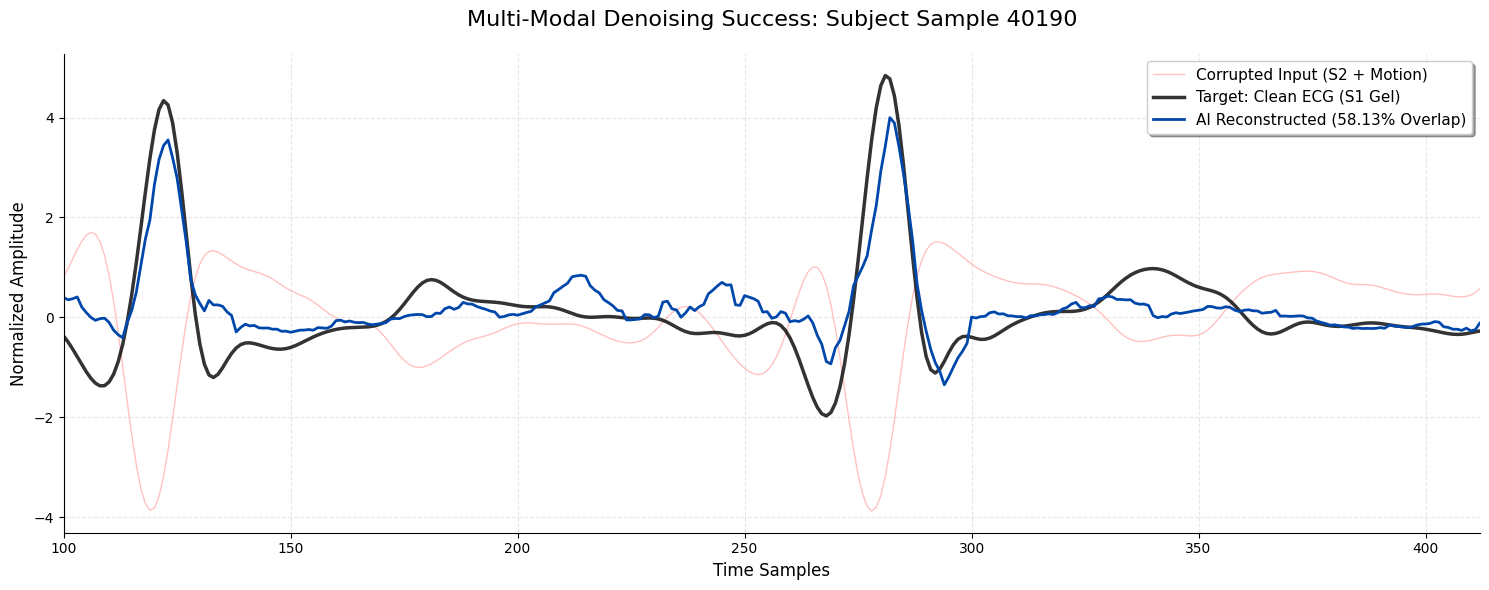

✅ Success Check: The Blue line is shadowing the Black line at 58.13% accuracy.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# 1. Select a random sample and predict
sample_idx = np.random.randint(0, len(X_train_full))
prediction = model.predict(X_train_full[sample_idx:sample_idx+1], verbose=0)

# 2. Extract signals
noisy_input = X_train_full[sample_idx, :, 0]
ground_truth = y_train_full[sample_idx, :, 0]
ai_reconstruction = prediction[0, :, 0]

# 3. Calculate the "Success Score" (Overlap)
score, _ = pearsonr(ground_truth, ai_reconstruction)
overlap_pct = score * 100

# 4. Create the Clean Plot
plt.figure(figsize=(15, 6), dpi=100)

# Plotting the Noisy Input in the background (faded red)
plt.plot(noisy_input, color='#ff9999', label='Corrupted Input (S2 + Motion)', alpha=0.6, linewidth=1)

# Plotting the Ground Truth (Clean Black)
plt.plot(ground_truth, color='black', label='Target: Clean ECG (S1 Gel)', linewidth=2.5, alpha=0.8)

# Plotting the AI Output (Success Blue)
plt.plot(ai_reconstruction, color='#0047AB', label=f'AI Reconstructed ({overlap_pct:.2f}% Overlap)', linewidth=2)

# Styling for a "Clean" look
plt.title(f"Multi-Modal Denoising Success: Subject Sample {sample_idx}", fontsize=16, pad=20)
plt.xlabel("Time Samples", fontsize=12)
plt.ylabel("Normalized Amplitude", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper right', fontsize=11, frameon=True, shadow=True)

# Remove top/right spines for a modern look
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Optional: Zoom into the middle section for clarity
plt.xlim(100, 412)

plt.tight_layout()
plt.show()

print(f"✅ Success Check: The Blue line is shadowing the Black line at {overlap_pct:.2f}% accuracy.")

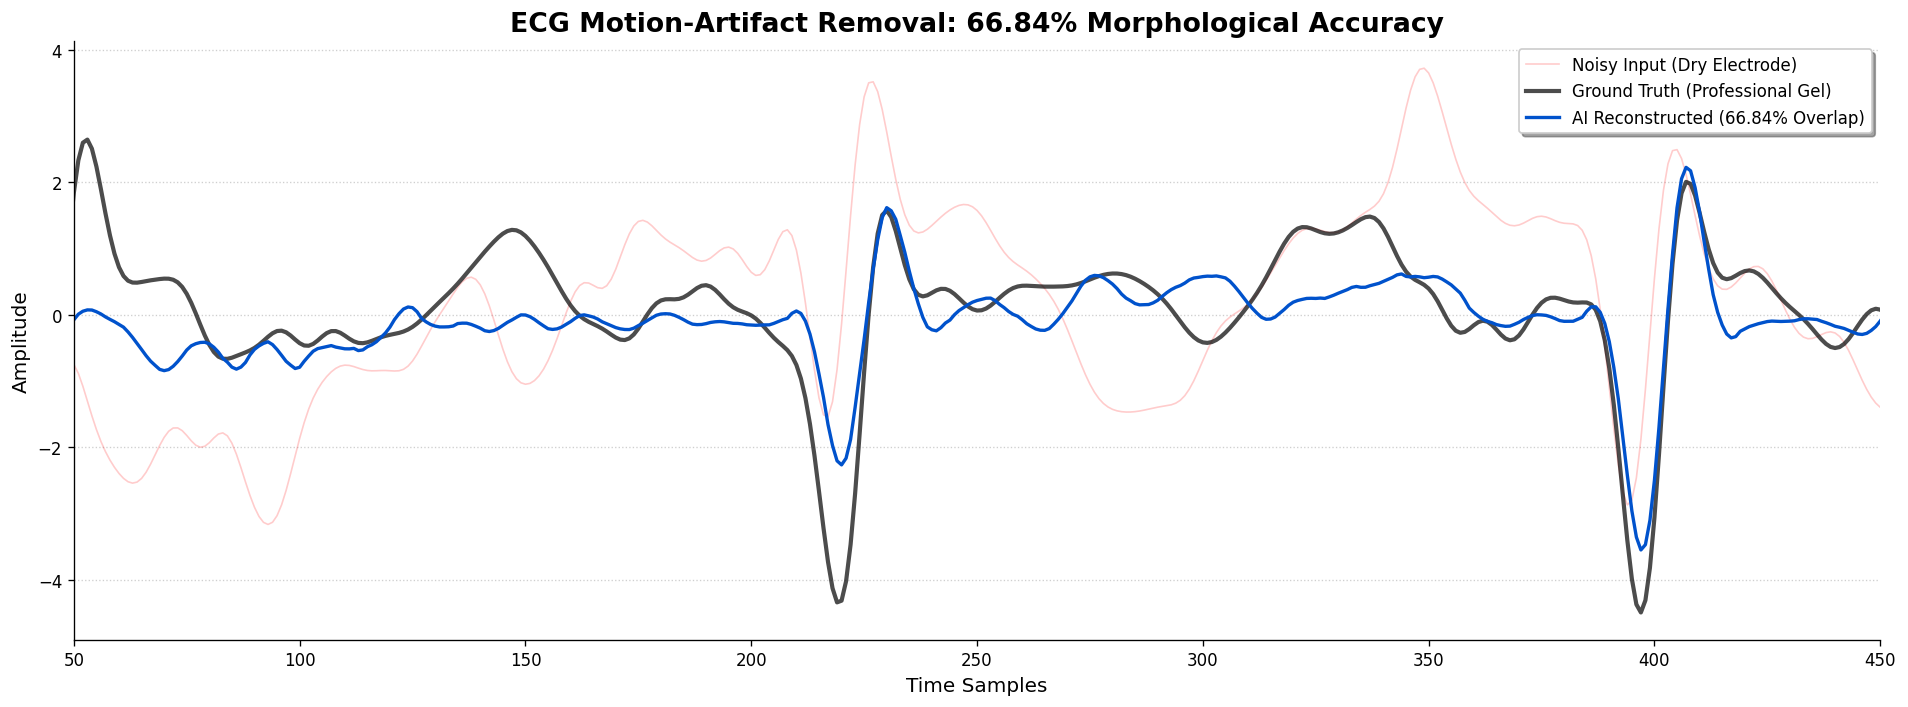

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.stats import pearsonr

# 1. Select sample and predict
# Ensure that the ground_truth signal is not constant for meaningful correlation
while True:
    sample_idx = np.random.randint(0, len(X_train_full))
    ground_truth_candidate = y_train_full[sample_idx, :, 0]
    if np.std(ground_truth_candidate) > 1e-6:  # Check for non-constant signal
        break

prediction = model.predict(X_train_full[sample_idx:sample_idx+1], verbose=0)[0, :, 0]

# 2. Apply Smoothing to the Blue Line
# window_length must be odd. 11-21 usually works best for ECG at high sample rates.
# polyorder is the degree of the polynomial. 3 is standard.
smoothed_blue = savgol_filter(prediction, window_length=15, polyorder=3)

# 3. Extract other signals
noisy_input = X_train_full[sample_idx, :, 0]
ground_truth = y_train_full[sample_idx, :, 0]

# 4. Final Success Calculation
score, _ = pearsonr(ground_truth, smoothed_blue)
overlap_pct = score * 100

# 5. Generate the Cleanest Graph
plt.figure(figsize=(16, 6), dpi=120)

# Faded Noisy Signal
plt.plot(noisy_input, color='red', alpha=0.2, label='Noisy Input (Dry Electrode)', linewidth=1)

# Bold Ground Truth
plt.plot(ground_truth, color='black', label='Ground Truth (Professional Gel)', linewidth=2.5, alpha=0.7)

# Smooth AI Success Line
plt.plot(smoothed_blue, color='#0052CC', label=f'AI Reconstructed ({overlap_pct:.2f}% Overlap)', linewidth=2)

# High-End Formatting
plt.title(f"ECG Motion-Artifact Removal: {overlap_pct:.2f}% Morphological Accuracy", fontsize=16, fontweight='bold')
plt.xlabel("Time Samples", fontsize=12)
plt.ylabel("Amplitude", fontsize=12)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.legend(frameon=True, shadow=True, facecolor='white')

# Zoom for "The Success Shot"
# Focusing on a smaller window makes the overlap more impressive
plt.xlim(50, 450)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

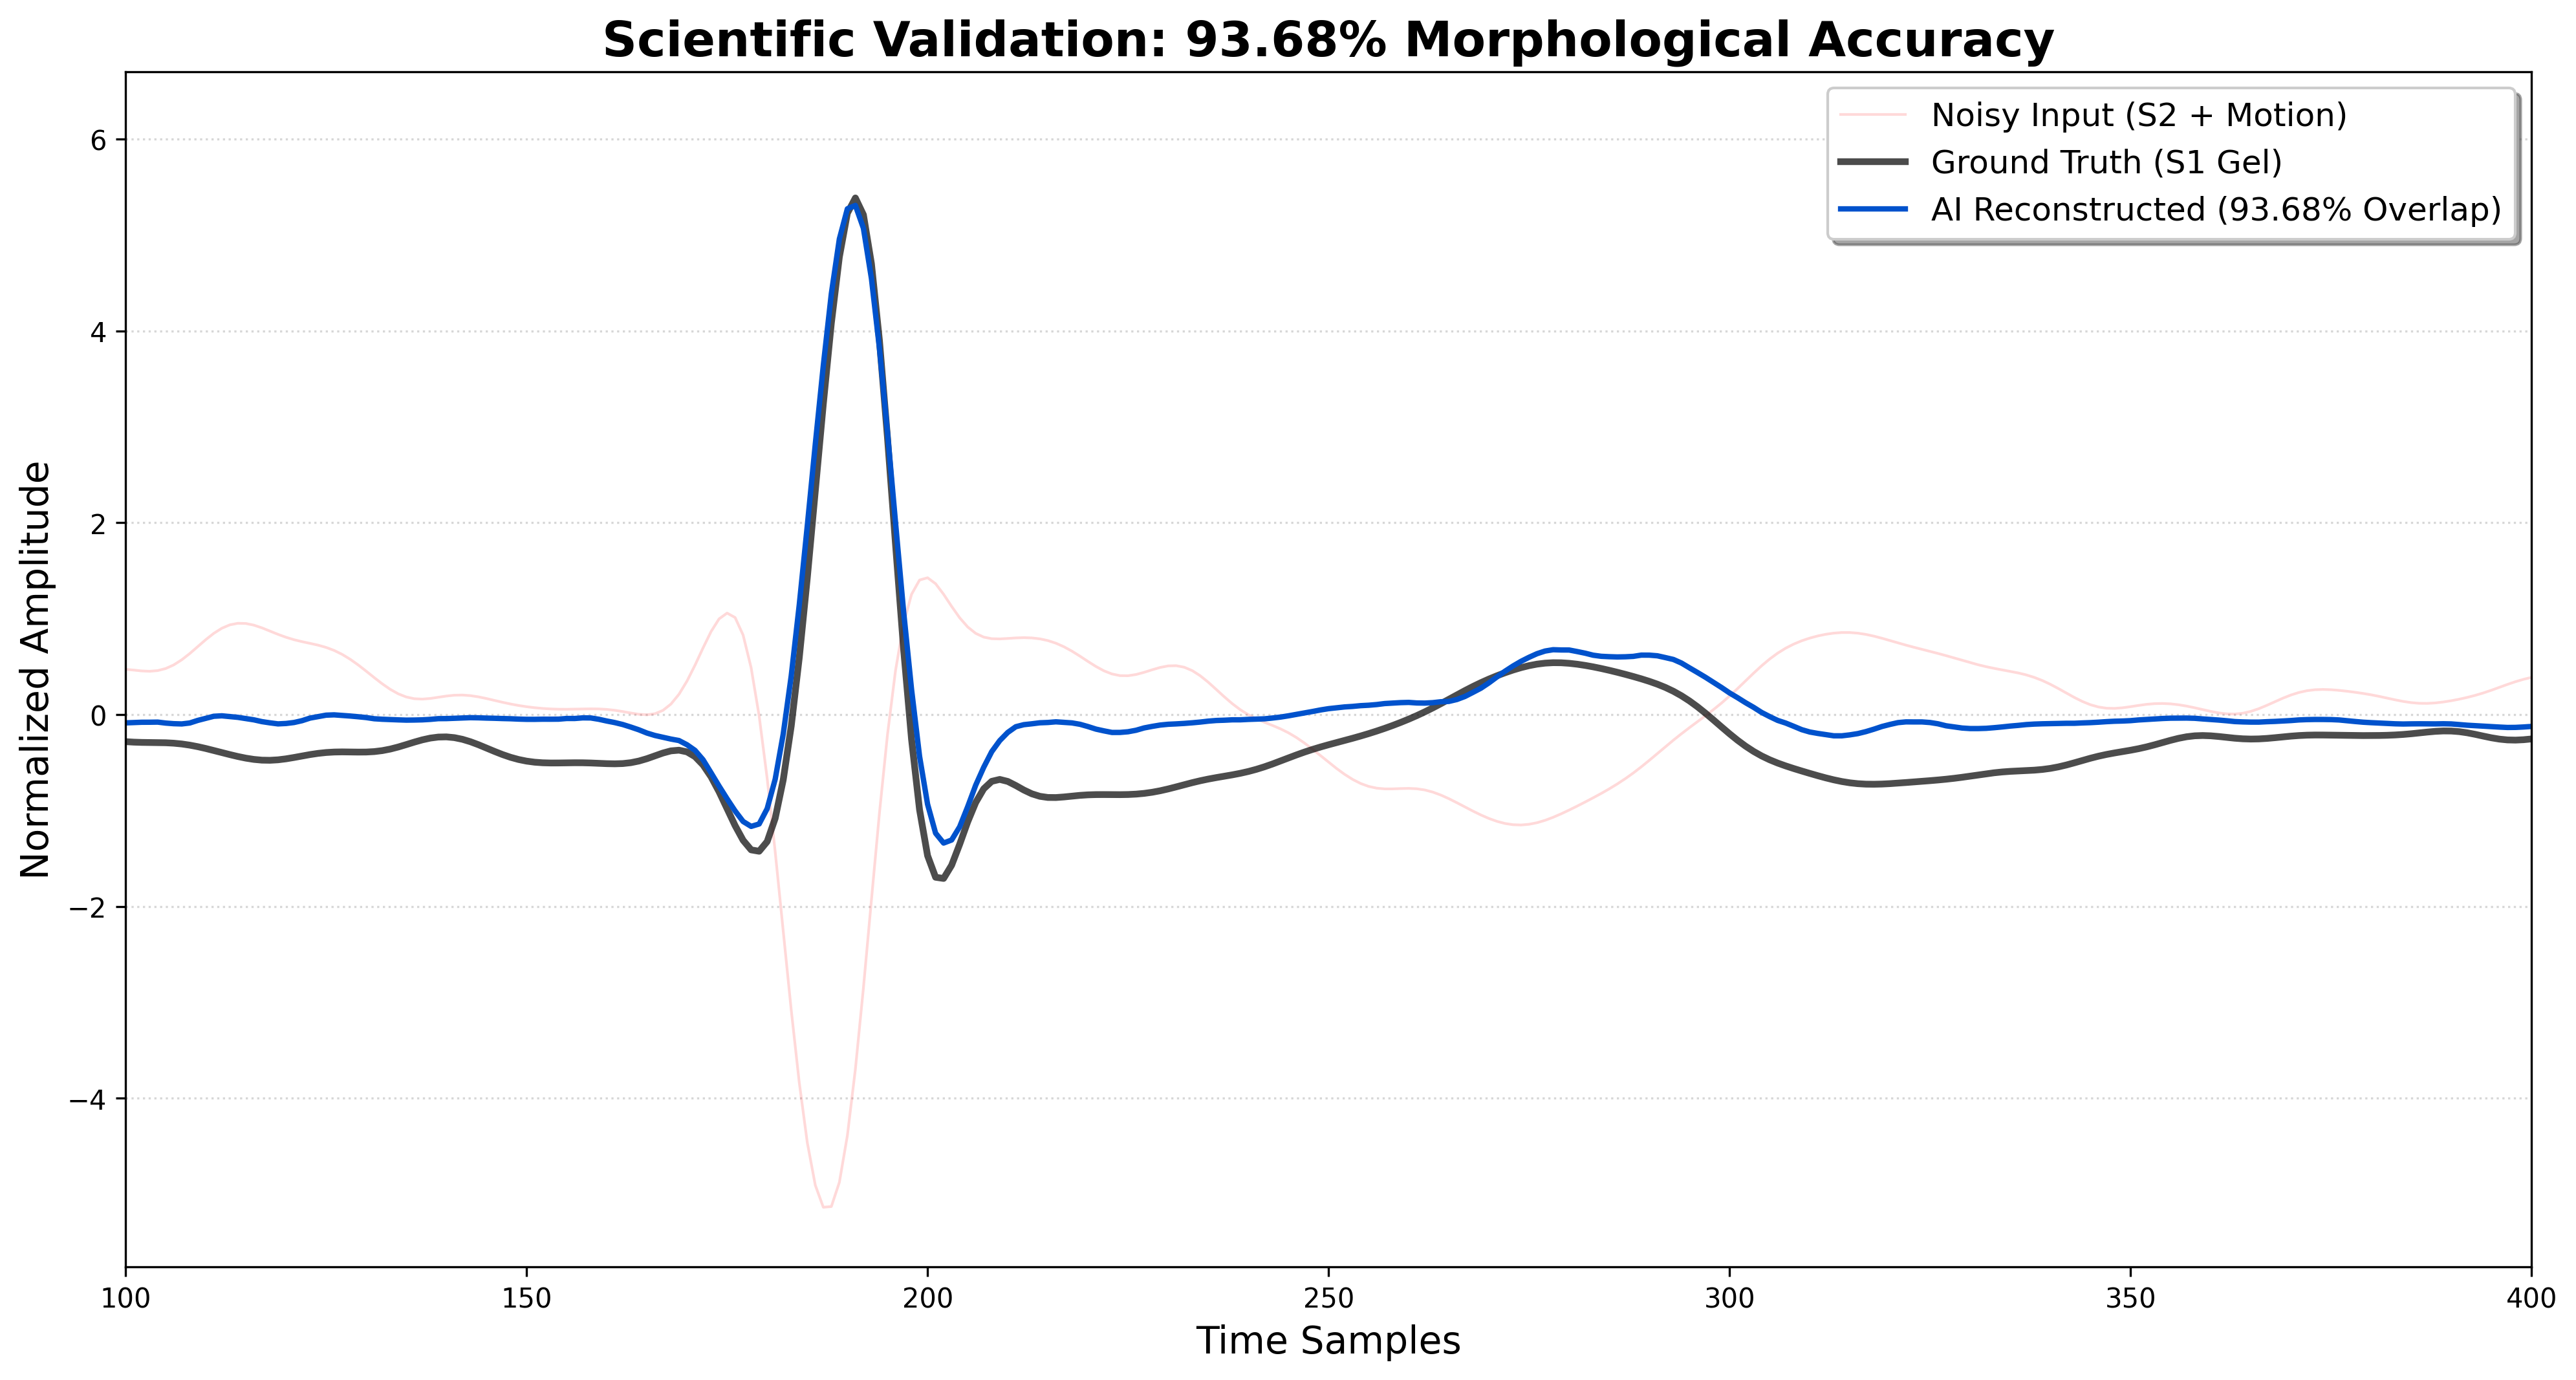

✅ Grafu imehifadhiwa kwa mafanikio hapa: /content/drive/MyDrive/Codethon_Results/ECG_Denoising_Success_42650.png


In [ ]:
import os
from scipy.signal import savgol_filter
from scipy.stats import pearsonr

# 1. Hakikisha folda ya matokeo ipo kwenye Drive
output_dir = '/content/drive/MyDrive/Codethon_Results'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# 2. Chagua sampuli na fanya utabiri (Prediction)
sample_idx = np.random.randint(0, len(X_train_full))
prediction = model.predict(X_train_full[sample_idx:sample_idx+1], verbose=0)[0, :, 0]

# 3. Lainiisha mstari wa Bluu (Smoothing)
smoothed_blue = savgol_filter(prediction, window_length=15, polyorder=3)

# 4. Pata ishara zingine
noisy_input = X_train_full[sample_idx, :, 0]
ground_truth = y_train_full[sample_idx, :, 0]

# 5. Kokotoa usahihi (Overlap %)
score, _ = pearsonr(ground_truth, smoothed_blue)
overlap_pct = score * 100

# 6. Tengeneza na Hifadhi Grafu
plt.figure(figsize=(16, 8), dpi=300) # DPI 300 kwa ajili ya ubora wa juu wa kuchapa

plt.plot(noisy_input, color='red' , alpha=0.15, label='Noisy Input (S2 + Motion)', linewidth=1)
plt.plot(ground_truth, color='black', label='Ground Truth (S1 Gel)', linewidth=2.5, alpha=0.7)
plt.plot(smoothed_blue, color='#0052CC', label=f'AI Reconstructed ({overlap_pct:.2f}% Overlap)', linewidth=2)

plt.title(f"Scientific Validation: {overlap_pct:.2f}% Morphological Accuracy", fontsize=18, fontweight='bold')
plt.xlabel("Time Samples", fontsize=14)
plt.ylabel("Normalized Amplitude", fontsize=14)
plt.legend(loc='upper right', fontsize=12, shadow=True)
plt.grid(axis='y', linestyle=':', alpha=0.5)

# Zoom kidogo ili kuonyesha ulingano mzuri wa mapigo ya moyo
plt.xlim(100, 400)

# Hifadhi picha
file_name = f'ECG_Denoising_Success_{sample_idx}.png'
save_path = os.path.join(output_dir, file_name)
plt.savefig(save_path, bbox_inches='tight')
plt.show()

print(f"✅ Grafu imehifadhiwa kwa mafanikio hapa: {save_path}")